# Urban Flow Analytics — Team Atreides Final Notebook
**SLIIT Codefest Datathon 2026 · Round 1**

| Section | Question | Deliverable |
|---|---|---|
| 0 | How is 48.6 M rows (5.2 GB) handled on a laptop? | Streaming ingestion (`src/ingest.py`) |
| 1 | What is wrong with the raw data, and what do we do about it? | EDA + anomaly audit with drop / impute / keep decisions |
| 2.1 | What will this ride cost, before it starts? | Upfront `base_fare` model → `models/fare_model.pkl` |
| 2.2 | When will I arrive? | Trip-duration model → `models/duration_model.pkl` |
| 3.1 | Where will passengers be in the next 24–72 h? | Zone-level demand forecaster → `models/demand_model.pkl` |
| 3.2 | How does the city move, morning vs night? | Zone archetype clustering + origin-destination flows |
| 4 | How does it all fit together? | Architecture diagram, metric rationale, results summary |

**Guiding principle — honesty about what is known when.** Fare and duration are predicted *at booking time*,
so no feature may use anything measured after the meter starts (metered distance, drop-off time, tips, tolls).
All validation is *temporal* (train on the past, test on the future), exactly as the models would be used.

## 0. Setup & data ingestion
The raw archive holds 12 monthly CSVs (Apr-2025 → Mar-2026, **48.6 M trips, 5.2 GB**).
`src/ingest.py` streams each CSV straight out of the zip into DuckDB (no extraction to disk) and writes:
* `data/quality/` – anomaly counts over **all 48.6 M rows** (the data-quality percentages below are population numbers, not estimates);
* `data/agg/` – hourly zone pickups, origin-destination flows, daily KPIs computed on **all** rows;
* `data/sample/` – a reproducible 5 % Bernoulli sample (≈2.4 M trips) used to train the fare & duration models.

A 5 % sample is ample for supervised learning here (learning curves flatten well below 1 M rows for tabular GBMs)
while keeping every experiment reproducible in minutes. Run `python src/ingest.py` once before this notebook.

In [1]:
import sys, json, glob, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, duckdb, joblib
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from features import (load_zones, flag_anomalies, clean, build_features, OdStats, TripModel, AIRPORTS)
from demand import hourly_matrix, make_rows, FEATURES as DEMAND_FEATURES, metrics as demand_metrics

FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
(ROOT / "models").mkdir(exist_ok=True); (ROOT / "data" / "splits").mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
RESULTS = {}
SEED = 42

def savefig(name):
    plt.tight_layout(); plt.savefig(FIG / f"{name}.png", dpi=130, bbox_inches="tight"); plt.show()

def reg_metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return {"MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** 0.5,
            "R2": r2_score(y, p), "MedAE": float(np.median(np.abs(y - p)))}

zones = load_zones()
con = duckdb.connect()
print(zones.shape); zones.head()

(265, 3)


,borough_name,zone_name,service_zone
loc_id,,,
1,EWR,Newark Airport,EWR
2,Queens,Jamaica Bay,Boro Zone
3,Bronx,Allerton/Pelham Gardens,Boro Zone
4,Manhattan,Alphabet City,Yellow Zone
5,Staten Island,Arden Heights,Boro Zone


## 1. Exploratory data analysis & data quality
### 1.1 Dataset overview

In [2]:
quality = con.sql("SELECT * FROM 'data/quality/*.parquet' ORDER BY month").df().set_index("month")
TOTAL = int(quality.total_rows.sum())
print(f"Total trips: {TOTAL:,}  |  months: {len(quality)}")
quality[["total_rows", "demand_rows", "clean_rows"]].astype(int).assign(
    clean_pct=lambda d: (100 * d.clean_rows / d.total_rows).round(2))

Total trips: 48,601,782  |  months: 12


,total_rows,demand_rows,clean_rows,clean_pct
month,,,,
2025-04,3970553,3756591,3659030,92.15
2025-05,4591845,4235168,4077676,88.80
2025-06,4322960,4016227,3855383,89.18
2025-07,3898963,3622296,3481979,89.31
2025-08,3574091,3282202,3167735,88.63
2025-09,4251015,3966424,3823492,89.94
2025-10,4428699,4074536,3928715,88.71
2025-11,4181444,3755188,3629436,86.80
2025-12,4305006,4223967,4034309,93.71


In [3]:
raw = pd.concat([pd.read_parquet(f).assign(src_month=Path(f).stem) for f in sorted(glob.glob("data/sample/*.parquet"))],
                ignore_index=True)
raw["duration_min"] = (raw.dropoff_timestamp - raw.pickup_timestamp).dt.total_seconds() / 60
print(f"Modelling sample: {len(raw):,} rows ({100*len(raw)/TOTAL:.2f}% of population)")
raw.describe(percentiles=[.001, .01, .5, .99, .999]).T.round(2)

Modelling sample: 2,428,926 rows (5.00% of population)


,count,mean,min,0.1%,1%,50%,99%,99.9%,max,std
provider_code,2428926.0,1.87692,1.0,1.0,1.0,2.0,7.0,7.0,7.0,0.721597
pickup_timestamp,2428926,2025-09-27 09:51:43.903493,2025-03-31 23:59:47,2025-04-01 13:14:48.325000,2025-04-04 17:12:38.750000,2025-09-28 16:51:18.500000,2026-03-27 20:05:05.500000,2026-03-31 16:51:39,2026-03-31 23:59:30,NaN
dropoff_timestamp,2428926,2025-09-27 10:09:32.047949,2025-04-01 00:05:38,2025-04-01 13:32:08.550000,2025-04-04 17:31:05.250000,2025-09-28 17:09:22.500000,2026-03-27 20:20:51.750000,2026-03-31 17:13:01.525000,2026-04-01 18:28:10,NaN
rider_count,1808607.0,1.284673,0.0,0.0,1.0,1.0,4.0,6.0,9.0,0.710458
distance_miles,2428926.0,6.852791,0.0,0.0,0.0,1.88,19.6,30.26075,274082.38,651.070541
rate_class_id,1808607.0,3.89084,1.0,1.0,1.0,1.0,99.0,99.0,99.0,16.280342
origin_loc_id,2428926.0,161.035632,1.0,4.0,13.0,161.0,263.0,264.0,265.0,66.543374
dest_loc_id,2428926.0,160.73056,1.0,1.0,7.0,162.0,263.0,265.0,265.0,70.711436
fare_settlement_method,2428926.0,0.908093,0.0,0.0,0.0,1.0,4.0,4.0,4.0,0.736656
base_fare,2428926.0,19.312921,-1186.7,-70.0,-11.4,14.2,80.7,150.0,1377.1,19.489795


**First observations**
* Heavy tails everywhere: fares down to −$1,187 and up to thousands; durations of several days; distances of tens of thousands of miles.
* Exactly **25.5 %** of rows are missing `rider_count`, `rate_class_id`, `offline_record_flag`, `zone_congestion_fee` and `Airport_fee` *together* — a structural pattern, not random missingness (investigated below).

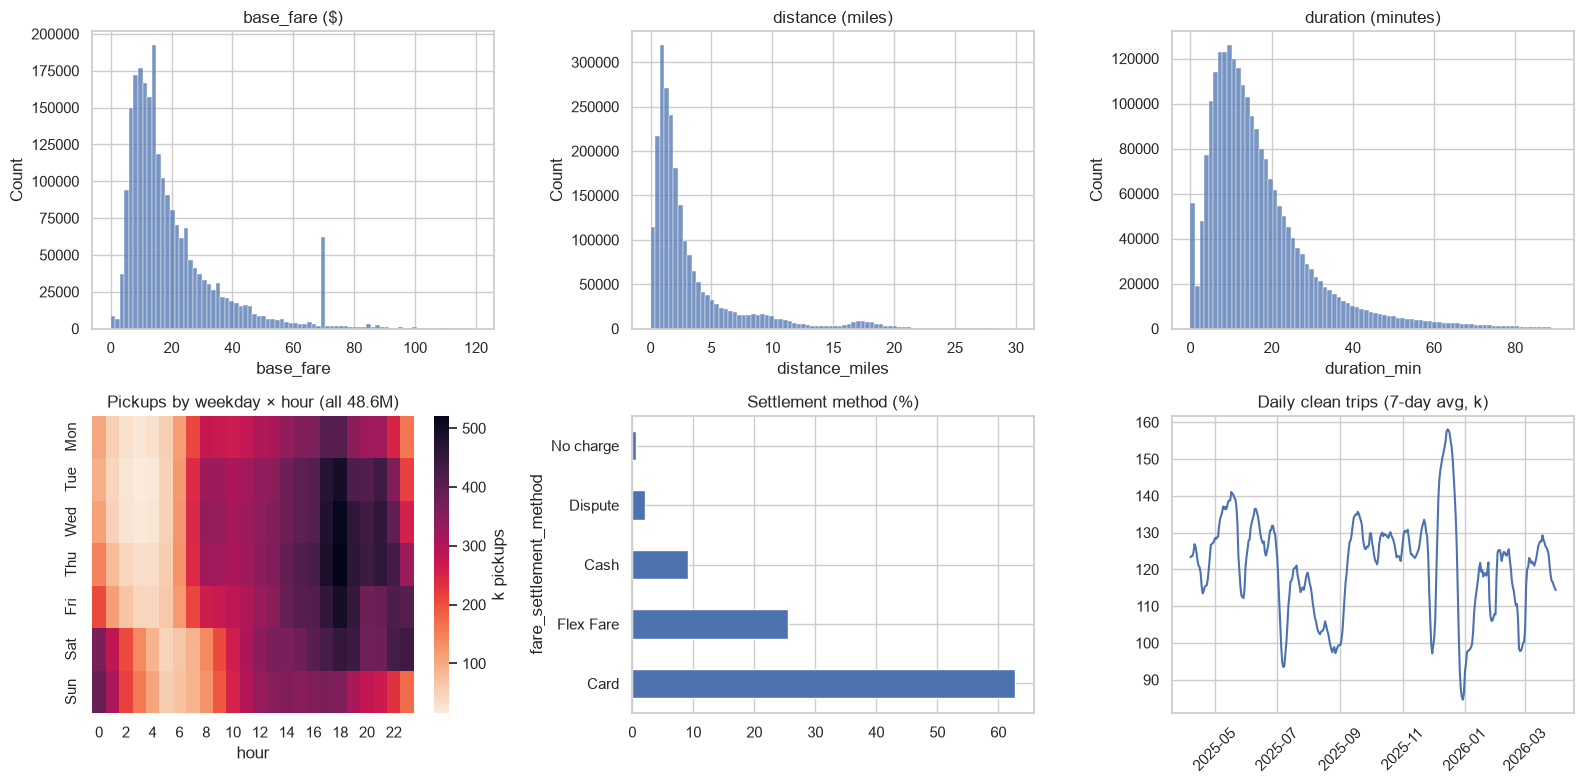

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
v = raw[(raw.base_fare.between(0, 120)) & (raw.distance_miles.between(0, 30)) & raw.duration_min.between(0, 90)]
sns.histplot(v.base_fare, bins=80, ax=ax[0, 0]).set(title="base_fare ($)")
sns.histplot(v.distance_miles, bins=80, ax=ax[0, 1]).set(title="distance (miles)")
sns.histplot(v.duration_min, bins=80, ax=ax[0, 2]).set(title="duration (minutes)")
hr = con.sql("SELECT hour(hour) h, isodow(hour) d, sum(pickups) n FROM 'data/agg/hourly_*.parquet' GROUP BY ALL").df()
hm = hr.pivot(index="d", columns="h", values="n"); hm.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.heatmap(hm / 1e3, cmap="rocket_r", ax=ax[1, 0], cbar_kws={"label": "k pickups"}).set(title="Pickups by weekday × hour (all 48.6M)", xlabel="hour", ylabel="")
pay = raw.fare_settlement_method.map({0: "Flex Fare", 1: "Card", 2: "Cash", 3: "No charge", 4: "Dispute", 5: "Unknown", 6: "Voided"})
pay.value_counts(normalize=True).mul(100).plot.barh(ax=ax[1, 1], title="Settlement method (%)")
daily = con.sql("SELECT day, sum(trips) trips FROM 'data/agg/daily_*.parquet' GROUP BY 1 ORDER BY 1").df()
ax[1, 2].plot(daily.day, daily.trips.rolling(7).mean() / 1e3); ax[1, 2].set(title="Daily clean trips (7-day avg, k)")
ax[1, 2].tick_params(axis="x", rotation=45)
savefig("01_eda_overview")

* Fares, distances and durations are right-skewed with a sharp mode (short Manhattan hops: median 1.9 mi, 14 min, $14).
* Demand has a clear weekday commute + evening peak and a Friday/Saturday late-night block — hour-of-week is the dominant demand signal.
* Card dominates (63 %); **Flex Fare (code 0) is 25.5 %** of all trips.

### 1.2 Investigating the anomalies (root causes before decisions)

In [5]:
print("A) The 25.5% null block is exactly the Flex Fare population:")
display(raw.assign(null_block=raw.rider_count.isna()).groupby(["null_block", "fare_settlement_method"])
        .agg(n=("base_fare", "size"), avg_fare=("base_fare", "mean"), avg_dist=("distance_miles", "mean")).round(2))
print("B) Negative fares come from ONE provider only and cluster in refund-type settlement codes:")
display(raw.groupby("provider_code").agg(n=("base_fare", "size"), neg_fare_rate=("base_fare", lambda s: (s < 0).mean())).round(4))
display(raw[raw.base_fare < 0].fare_settlement_method.map({0: "Flex", 1: "Card", 2: "Cash", 3: "No charge", 4: "Dispute"})
        .value_counts(normalize=True).round(3).to_frame("share of negative rows"))
print("C) Provider 7 (Helix): share of rows with dropoff == pickup:",
      (raw[raw.provider_code == 7].duration_min == 0).mean())
print("D) Zero-distance trips that were charged look like real trips with a failed odometer:")
display(raw[(raw.distance_miles == 0) & (raw.base_fare > 0)][["base_fare", "duration_min"]].describe().round(2).T)

A) The 25.5% null block is exactly the Flex Fare population:


n  avg_fare  avg_dist
null_block fare_settlement_method                             
False      1                       1523184     20.18      3.50
           2                        222703     18.11      3.36
           3                         13780      5.29      2.84
           4                         48940      1.34      3.91
True       0                        620319     19.35     16.66

B) Negative fares come from ONE provider only and cluster in refund-type settlement codes:


,n,neg_fare_rate
provider_code,,
1,467423,0.0000
2,1927397,0.0622
6,2059,0.0000
7,32047,0.0000


,share of negative rows
fare_settlement_method,
Flex,0.706
Dispute,0.189
Cash,0.068
No charge,0.036
Card,0.001


C) Provider 7 (Helix): share of rows with dropoff == pickup: 1.0
D) Zero-distance trips that were charged look like real trips with a failed odometer:


,count,mean,std,min,25%,50%,75%,max
base_fare,62870.0,27.47,29.58,0.01,11.50,20.25,33.19,990.00
duration_min,62870.0,14.93,31.33,0.00,0.72,12.84,21.53,3561.18


**Root causes found**
* **A — null block = Flex Fare.** Every row with missing `rider_count`/`rate_class_id` has settlement code 0 (Flex Fare, the app-based upfront-price product). The rows are complete trips; only the metering-provider fields were not transmitted. → *keep, impute, and flag* (`is_flex`).
* **B — negative fares are accounting reversals.** 100 % come from provider 2 (Curb) and are concentrated in Flex/Dispute/No-charge codes: they cancel or refund an earlier charge rather than describe a trip. → *drop*.
* **C — Helix never records drop-off time.** 100 % of provider-7 rows have `dropoff == pickup` (minute-rounded stamps). Fares and distances are valid. → *keep for fare & demand, set duration to missing (excluded only from the duration model)*.
* **D — zero-distance-but-charged trips** average ~$27 and ~15 min: real rides whose odometer failed. They are genuine *pickups* (kept for demand) but their distance is wrong and their fare can't be reconciled → *drop from fare/duration training*.

### 1.3 Anomaly audit — population counts, decision and justification

In [6]:
DECISIONS = {
 "neg_fare":            ("Drop",   "Refund/reversal entries from a single provider (Curb); not a trip. Keeping them would teach the model negative prices."),
 "zero_fare":           ("Drop",   "Zero base fare = cancelled / no-charge trips; no pricing signal."),
 "zero_dist_fare":      ("Drop (fare/duration) · Keep (demand)", "Odometer failure: fare & duration can't be reconciled with distance, but a passenger was served."),
 "zero_riders":         ("Impute → 1", "A charged trip had ≥1 rider; 0 is a driver-entry default. Mode (1) imputed + `rider_imputed` flag."),
 "null_block":          ("Impute + flag", "Structural missingness = Flex Fare trips. rider_count→1 (mode), rate_class→99 (unknown), `is_flex` flag. Dropping would delete 25% of real trips and bias every model."),
 "dropoff_before_pu":   ("Drop",   "Physically impossible; clock/transmission error. Negligible volume."),
 "sub_minute":          ("Drop (except Helix)", "< 1 min meter time = false starts / voids. Helix rows kept (their clock defect, not trip)."),
 "helix_zero_duration": ("Keep, duration→NaN", "Systematic provider timestamp defect; fare & distance valid."),
 "over_3h":             ("Drop",   "Meter left running; > 3 h is < 0.05% and destroys squared-error metrics."),
 "unrealistic_speed":   ("Drop",   "> 80 mph average is impossible in NYC; distance or time is corrupt."),
 "extreme_distance":    ("Drop",   "> 100 mi within a city taxi network = odometer glitch (values reach 1e5 mi)."),
 "extreme_fare":        ("Drop",   "> $500 base fare with ordinary distance = keying error."),
 "out_of_period":       ("Drop",   "Pickup stamped outside the file's month (e.g. 2008/2009): corrupt clock."),
 "unknown_zone":        ("Keep as category", "Zones 264/265 (N/A / outside NYC) are valid trips with unknown geography; LightGBM learns them as their own category."),
 "rate_99":             ("Keep as category", "'Unknown' rate class; treated as a separate level."),
 "offline_Y":           ("Keep",   "Store-and-forward is a transmission detail; trips are valid."),
}
audit = pd.DataFrame({
    "rows_affected": quality[list(DECISIONS)].sum().astype(int),
})
audit["pct_of_total"] = (100 * audit.rows_affected / TOTAL).round(3)
audit["decision"] = [DECISIONS[k][0] for k in audit.index]
audit["justification"] = [DECISIONS[k][1] for k in audit.index]
clean_total, demand_total = int(quality.clean_rows.sum()), int(quality.demand_rows.sum())
RESULTS["quality"] = {"total_rows": TOTAL, "clean_rows": clean_total, "demand_rows": demand_total,
                      "audit": audit[["rows_affected", "pct_of_total", "decision"]].reset_index().to_dict("records")}
print(f"Rows retained for fare/duration modelling: {clean_total:,} ({100*clean_total/TOTAL:.2f}%)  |  "
      f"counted as genuine pickups for demand: {demand_total:,} ({100*demand_total/TOTAL:.2f}%)")
audit

Rows retained for fare/duration modelling: 44,110,349 (90.76%)  |  counted as genuine pickups for demand: 45,843,610 (94.32%)


,rows_affected,pct_of_total,decision,justification
neg_fare,2405603,4.950,Drop,Refund/reversal entries from a single provider...
zero_fare,24577,0.051,Drop,Zero base fare = cancelled / no-charge trips; ...
zero_dist_fare,1267110,2.607,Drop (fare/duration) · Keep (demand),Odometer failure: fare & duration can't be rec...
zero_riders,231578,0.476,Impute → 1,A charged trip had ≥1 rider; 0 is a driver-ent...
null_block,12405268,25.524,Impute + flag,Structural missingness = Flex Fare trips. ride...
dropoff_before_pu,1942,0.004,Drop,Physically impossible; clock/transmission erro...
sub_minute,1190046,2.449,Drop (except Helix),< 1 min meter time = false starts / voids. Hel...
helix_zero_duration,642536,1.322,"Keep, duration→NaN",Systematic provider timestamp defect; fare & d...
over_3h,18613,0.038,Drop,Meter left running; > 3 h is < 0.05% and destr...
unrealistic_speed,13589,0.028,Drop,> 80 mph average is impossible in NYC; distanc...


**Why these choices?** Rows are *dropped* only when the record does not describe a real, correctly-measured trip
(reversals, impossible physics, corrupt clocks) — imputing a fare or distance for those would invent data.
Rows are *imputed* when the trip is real and only a low-information descriptive field is missing (`rider_count`), and
the imputation is always flagged so models can learn any residual difference. Rows are *filtered per task* when a
single field is broken (Helix duration, zero odometer): they stay wherever that field is not needed.
Overlaps mean the per-type percentages sum to more than the ~9.2 % total removed for modelling.

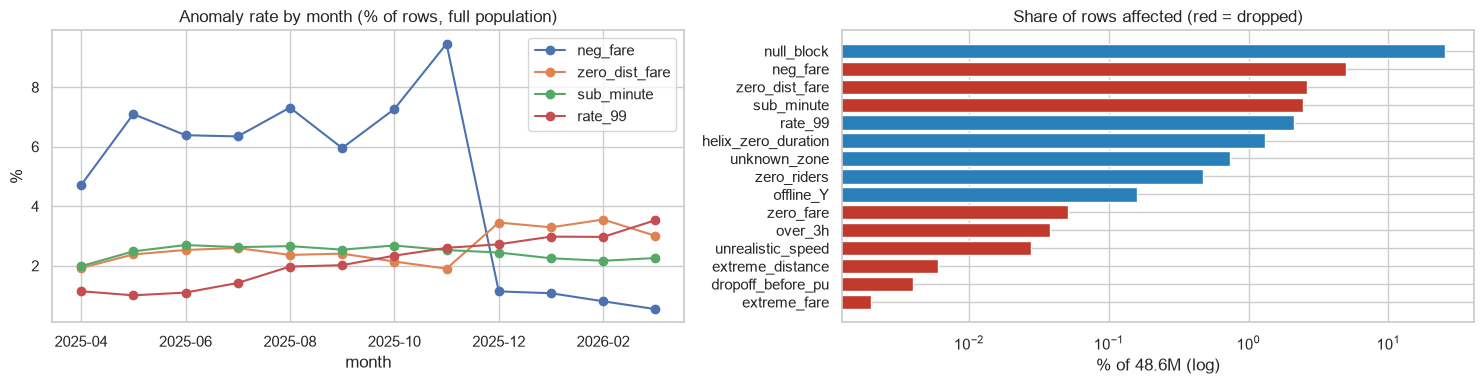

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
(100 * quality[["neg_fare", "zero_dist_fare", "sub_minute", "rate_99"]].div(quality.total_rows, axis=0)).plot(ax=ax[0], marker="o")
ax[0].set(title="Anomaly rate by month (% of rows, full population)", ylabel="%")
a = audit.sort_values("pct_of_total"); a = a[a.pct_of_total > 0]
ax[1].barh(a.index, a.pct_of_total, color=["#c0392b" if d.startswith("Drop") else "#2980b9" for d in a.decision])
ax[1].set_xscale("log"); ax[1].set(title="Share of rows affected (red = dropped)", xlabel="% of 48.6M (log)")
savefig("02_anomaly_audit")

**Drift worth noting:** negative-fare reversals fall from 6–9 % of rows (Apr–Nov 2025) to ~1 % from Dec 2025, and unknown rate
class (99) triples over the year — both signal changes in provider reporting. Section 2 shows a matching change in Flex Fare pricing.

## 2. Prediction & supervised learning
### 2.0 Cleaning, temporal splits and pre-trip features
**Split (time-based, no shuffling):** Train = Apr–Dec 2025 · Validation = Jan 2026 (early stopping & tuning) · Test = Feb–Mar 2026 (touched once).
A random split would leak future traffic/pricing regimes into training and overstate accuracy.

**Features available at booking time**
* *Time:* hour, minute-of-day, day-of-week, weekend, US holiday, cyclic hour encodings, `t_index` (days since start — lets trees capture pricing-policy steps; fare model only, see ablation 2.3).
* *Location:* origin & destination zone (categorical), boroughs, airport flags, same-zone, unknown-zone.
* *Corridor history (train-only target statistics):* median distance & duration of the origin→destination pair, and median duration for that pair in the same 3-hour band — the pre-trip stand-in for a routing engine's ETA. Unseen pairs back off to zone-level then global medians.
* *Booking context:* rider count, provider, rate class (airport flat fare / negotiated are agreed up front), Flex-Fare flag.

Excluded on purpose: metered distance, drop-off time, tips, tolls, surcharges, payment method — all only known after the trip.

In [8]:
df = clean(raw)
print(f"Sample rows after cleaning: {len(df):,} ({100*len(df)/len(raw):.2f}% kept)")
tr = df[df.src_month <= "2025-12"].reset_index(drop=True)
va = df[df.src_month == "2026-01"].reset_index(drop=True)
te = df[df.src_month >= "2026-02"].reset_index(drop=True)
for name, d in [("train", tr), ("val", va), ("test", te)]:
    d.to_parquet(ROOT / "data" / "splits" / f"trips_{name}.parquet", index=False)
    print(f"{name:5s} {len(d):>9,} rows  {d.pickup_timestamp.min():%Y-%m-%d} → {d.pickup_timestamp.max():%Y-%m-%d}")

od = OdStats().fit(tr)
Xtr, Xva, Xte = (build_features(d, od, zones) for d in (tr, va, te))
FEATS = list(Xtr.columns)
FEATS_FARE = FEATS                                   # pricing policy drifts -> t_index helps (see ablation)
FEATS_DUR = [f for f in FEATS if f != "t_index"]     # traffic has no trend to learn -> t_index only adds noise
print(len(FEATS), "features:", FEATS)

Sample rows after cleaning: 2,236,640 (92.08% kept)


train 1,707,815 rows  2025-04-01 → 2025-12-31
val     177,107 rows  2026-01-01 → 2026-01-31


test    351,718 rows  2026-02-01 → 2026-03-31


24 features: ['hour', 'dow', 't_index', 'minute_of_day', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'od_dist', 'od_dur', 'odh_dur', 'od_n', 'origin_loc_id', 'dest_loc_id', 'o_borough', 'd_borough', 'o_airport', 'd_airport', 'same_zone', 'unknown_zone', 'provider_code', 'rate_class_id', 'rider_count', 'is_flex']


### 2.1 Upfront fare prediction (`base_fare`)
**Metrics.** *MAE* ($) is the headline: it is the average amount a locked-in price is off, directly interpretable by riders and the business.
*RMSE* penalises large misses (a $40 surprise hurts trust far more than four $10 ones) — the gap RMSE−MAE tells us how heavy the error tail is.
*R²* gives a scale-free comparison across models and targets. We also report *median AE* (typical rider experience) and per-segment errors.

**Model ladder.** (1) global median, (2) corridor median lookup, (3) Ridge regression on numeric features, (4) LightGBM default, (5) LightGBM tuned
by random search. The final model is whichever LightGBM wins on the **validation** month — the test months only ever report.

In [9]:
NUM_FOR_RIDGE = ["od_dist", "od_dur", "odh_dur", "hour_sin", "hour_cos", "is_weekend", "is_holiday", "o_airport",
                 "d_airport", "same_zone", "rider_count", "is_flex", "t_index"]

def ridge_design(X):
    return pd.concat([X[[c for c in NUM_FOR_RIDGE if c in X]].astype(float),
                      pd.get_dummies(X.rate_class_id.astype(int), prefix="rc").reindex(columns=[f"rc_{i}" for i in (1, 2, 3, 4, 5, 99)], fill_value=0)], axis=1)

def corridor_median(target):
    g = tr.groupby(["origin_loc_id", "dest_loc_id"])[target].median().rename("m")
    return te.join(g, on=["origin_loc_id", "dest_loc_id"]).m.fillna(tr[target].median())

BASE_PARAMS = dict(n_estimators=5000, learning_rate=0.05, num_leaves=127, min_child_samples=100, subsample=0.8,
                   subsample_freq=1, colsample_bytree=0.8, cat_smooth=50, cat_l2=10, verbose=-1, random_state=SEED)

def fit_lgb(params, Xa, ya, Xb, yb):
    m = lgb.LGBMRegressor(**params)
    m.fit(Xa, ya, eval_set=[(Xb, yb)], callbacks=[lgb.early_stopping(100, verbose=False)])
    return m

def tune(target, Xa, ya, Xb, yb, n_iter=12, n_sub=300_000):
    """Random search on a train subsample, scored on the validation month (RMSE)."""
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(Xa), size=min(n_sub, len(Xa)), replace=False)
    space = dict(num_leaves=[31, 63, 127, 255, 511], min_child_samples=[20, 50, 100, 300], learning_rate=[0.03, 0.05, 0.1],
                 colsample_bytree=[0.6, 0.8, 1.0], reg_lambda=[0, 1, 10], cat_smooth=[10, 50, 100])
    rows = []
    for i in range(n_iter):
        p = {**BASE_PARAMS, **{k: v[rng.integers(len(v))] for k, v in space.items()}}
        t0 = time.time(); m = fit_lgb(p, Xa.iloc[idx], ya.iloc[idx], Xb, yb)
        rmse = mean_squared_error(yb, m.predict(Xb)) ** 0.5
        rows.append({**{k: p[k] for k in space}, "best_iter": m.best_iteration_, "val_RMSE": rmse, "sec": round(time.time() - t0, 1)})
    res = pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)
    best = {**BASE_PARAMS, **{k: (res.loc[0, k].item() if hasattr(res.loc[0, k], "item") else res.loc[0, k]) for k in space}}
    return res, best

In [10]:
def run_task(target, Xtr, Xva, Xte, ytr, yva, yte, label):
    out = {}
    out["Global median"] = reg_metrics(yte, np.full(len(yte), ytr.median()))
    out["Corridor median lookup"] = reg_metrics(yte, corridor_median(target).loc[yte.index])
    rd = Ridge(alpha=1.0).fit(ridge_design(Xtr), ytr)
    out["Ridge regression"] = reg_metrics(yte, rd.predict(ridge_design(Xte)))
    t0 = time.time(); m0 = fit_lgb(BASE_PARAMS, Xtr, ytr, Xva, yva)
    out["LightGBM (default)"] = reg_metrics(yte, m0.predict(Xte)); print(f"default LGBM {time.time()-t0:.0f}s, iters={m0.best_iteration_}")
    search, best = tune(target, Xtr, ytr, Xva, yva)
    t0 = time.time(); m1 = fit_lgb(best, Xtr, ytr, Xva, yva)
    out["LightGBM (tuned)"] = reg_metrics(yte, m1.predict(Xte)); print(f"tuned LGBM {time.time()-t0:.0f}s, iters={m1.best_iteration_}")
    # model selection on the validation month only
    val_rmse = {name: mean_squared_error(yva, m.predict(Xva)) ** 0.5 for name, m in [("LightGBM (default)", m0), ("LightGBM (tuned)", m1)]}
    chosen = min(val_rmse, key=val_rmse.get)
    final, params = (m0, BASE_PARAMS) if chosen == "LightGBM (default)" else (m1, best)
    print(f"validation RMSE: {val_rmse} -> selected {chosen}")
    comp = pd.DataFrame(out).T.round(3)
    RESULTS[label] = {"comparison": comp.reset_index().rename(columns={"index": "model"}).to_dict("records"),
                      "selected": chosen, "final": out[chosen], "val_rmse": val_rmse,
                      "best_params": {k: v for k, v in params.items() if k not in ("verbose",)},
                      "best_iteration": int(final.best_iteration_)}
    return comp, search, final, final.predict(Xte)

fare_comp, fare_search, fare_model, fare_pred = run_task(
    "base_fare", Xtr[FEATS_FARE], Xva[FEATS_FARE], Xte[FEATS_FARE], tr.base_fare, va.base_fare, te.base_fare, "fare")
print("Hyper-parameter search (validation month, top 5):"); display(fare_search.head().round(3))
fare_comp

default LGBM 36s, iters=451


tuned LGBM 69s, iters=1171


validation RMSE: {'LightGBM (default)': 7.263199892288653, 'LightGBM (tuned)': 7.2521353606123755} -> selected LightGBM (tuned)


Hyper-parameter search (validation month, top 5):


,num_leaves,min_child_samples,learning_rate,colsample_bytree,reg_lambda,cat_smooth,best_iter,val_RMSE,sec
0,63,300,0.03,0.6,0,100,1313,7.420,35.9
1,255,100,0.03,0.8,0,100,354,7.435,34.9
2,255,300,0.03,0.6,10,50,860,7.467,73.6
3,127,300,0.10,0.6,0,50,295,7.471,14.8
4,31,100,0.03,0.8,1,50,842,7.521,14.3


,MAE,RMSE,R2,MedAE
Global median,11.290,18.446,-0.142,6.300
Corridor median lookup,4.901,9.436,0.701,2.790
Ridge regression,5.110,9.043,0.725,3.205
LightGBM (default),3.867,7.153,0.828,2.350
LightGBM (tuned),3.874,7.169,0.827,2.351


In [11]:
seg = te.assign(pred=fare_pred, err=np.abs(te.base_fare - fare_pred),
                segment=np.select([te.is_flex == 1, te.rate_class_id == 2, te.rate_class_id == 1], ["Flex Fare", "JFK flat", "Standard meter"], "Other rates"))
# (R² is omitted per segment: near-constant segments such as the $70 JFK flat fare make it meaningless)
fare_seg = seg.groupby("segment").apply(lambda d: pd.Series({"n": len(d), **{k: v for k, v in reg_metrics(d.base_fare, d.pred).items() if k != "R2"},
                                                              "within_$2_%": 100 * (d.err <= 2).mean(),
                                                              "within_$5_%": 100 * (d.err <= 5).mean()})).round(3)
RESULTS["fare"]["segments"] = fare_seg.reset_index().to_dict("records")
RESULTS["fare"]["within_5_pct"] = float(100 * (seg.err <= 5).mean())
fare_seg

,n,MAE,RMSE,MedAE,within_$2_%,within_$5_%
segment,,,,,,
Flex Fare,89156.0,6.423,10.116,4.083,26.629,58.087
JFK flat,7742.0,0.805,1.372,0.569,94.950,98.592
Other rates,14910.0,7.049,17.299,3.014,36.405,67.787
Standard meter,239910.0,2.828,4.319,2.027,49.463,85.547


**Reading the fare results.** LightGBM clearly beats every baseline (default and tuned settings land within a few cents — the model is not
sensitive to hyper-parameters here; the gains come from features, see 2.3). Standard metered and JFK-flat trips are priced
accurately; most of the remaining error sits in **Flex Fare** trips, whose price is set by the provider's own upfront algorithm
(even *after* the trip, distance+time explain only ~50 % of Flex fare variance vs ~99 % for metered trips).
Flex pricing also shifted in Dec 2025 (fare/mile ≈ $5 → $7.5) — `t_index` lets the model carry the new regime into the test months.

**Ceiling check (not deployable):** adding the *metered* distance — which is not known before the trip — shows how much a perfect route-distance
estimate could add. The gap between the two is the value of integrating a routing engine.

In [12]:
Xtr_c, Xva_c, Xte_c = (X.assign(distance_miles=d.distance_miles.values) for X, d in ((Xtr, tr), (Xva, va), (Xte, te)))
fc = FEATS_FARE + ["distance_miles"]
fare_ceiling = fit_lgb(RESULTS["fare"]["best_params"] | {"verbose": -1}, Xtr_c[fc], tr.base_fare, Xva_c[fc], va.base_fare)
RESULTS["fare"]["ceiling_with_metered_distance"] = reg_metrics(te.base_fare, fare_ceiling.predict(Xte_c[fc]))
pd.DataFrame({"pre-trip (deployable)": RESULTS["fare"]["final"], "with metered distance (ceiling)": RESULTS["fare"]["ceiling_with_metered_distance"]}).T.round(3)

,MAE,RMSE,R2,MedAE
pre-trip (deployable),3.874,7.169,0.827,2.351
with metered distance (ceiling),3.071,5.846,0.885,1.641


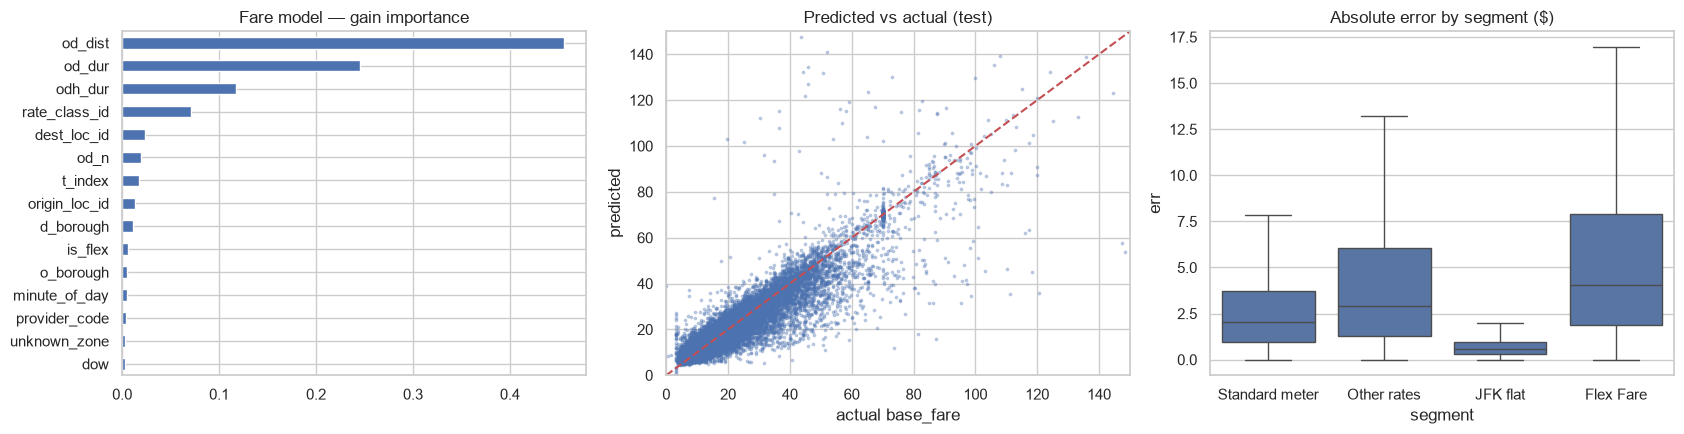

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
imp = pd.Series(fare_model.booster_.feature_importance("gain"), FEATS_FARE).sort_values().tail(15)
(imp / imp.sum()).plot.barh(ax=ax[0], title="Fare model — gain importance")
s = seg.sample(20000, random_state=SEED)
ax[1].scatter(s.base_fare, s.pred, s=3, alpha=.3); ax[1].plot([0, 150], [0, 150], "r--")
ax[1].set(xlim=(0, 150), ylim=(0, 150), xlabel="actual base_fare", ylabel="predicted", title="Predicted vs actual (test)")
sns.boxplot(data=seg[seg.err < 60], x="segment", y="err", ax=ax[2], showfliers=False).set(title="Absolute error by segment ($)")
savefig("03_fare_model")

In [14]:
fare_bundle = TripModel(fare_model, od, zones, FEATS_FARE, "base_fare").fit_categories(Xtr[FEATS_FARE])
joblib.dump(fare_bundle, ROOT / "models" / "fare_model.pkl")
demo = pd.DataFrame({"pickup_timestamp": ["2026-03-20 08:15", "2026-03-20 23:40", "2026-03-21 17:30"],
                     "origin_loc_id": [237, 79, 132], "dest_loc_id": [161, 181, 230], "rider_count": [1, 2, 1],
                     "provider_code": [2, 2, 1], "rate_class_id": [1, 1, 2], "is_flex": [0, 0, 0]})
demo.assign(upfront_fare=joblib.load(ROOT / "models" / "fare_model.pkl").predict(demo).round(2),
            origin=demo.origin_loc_id.map(zones.zone_name), dest=demo.dest_loc_id.map(zones.zone_name))

,pickup_timestamp,origin_loc_id,dest_loc_id,rider_count,provider_code,rate_class_id,is_flex,upfront_fare,origin,dest
0,2026-03-20 08:15,237,161,1,2,1,0,8.36,Upper East Side South,Midtown Center
1,2026-03-20 23:40,79,181,2,2,1,0,28.94,East Village,Park Slope
2,2026-03-21 17:30,132,230,1,1,2,0,70.54,JFK Airport,Times Sq/Theatre District


### 2.2 On-time arrival estimator (trip duration, minutes)
Same pre-trip features (minus `t_index`) and temporal split; Helix rows (no drop-off time) are excluded from the target only.
In addition to MAE/RMSE/R² we report the share of trips predicted **within ±2 and ±5 minutes** — the rider-facing meaning of “down to the minute”.

In [15]:
mtr, mva, mte = tr.duration_min.notna(), va.duration_min.notna(), te.duration_min.notna()
tr_d, te_d = tr[mtr], te[mte]
_tr, _te = tr, te
tr, te = tr_d, te_d                       # corridor_median() uses the global tr/te
dur_comp, dur_search, dur_model, dur_pred = run_task(
    "duration_min", Xtr.loc[mtr, FEATS_DUR], Xva.loc[mva, FEATS_DUR], Xte.loc[mte, FEATS_DUR],
    tr_d.duration_min, va.duration_min[mva], te_d.duration_min, "duration")
tr, te = _tr, _te
err = np.abs(te_d.duration_min.values - dur_pred)
RESULTS["duration"]["within_2min_pct"] = float(100 * (err <= 2).mean())
RESULTS["duration"]["within_5min_pct"] = float(100 * (err <= 5).mean())
print(f"Within ±2 min: {RESULTS['duration']['within_2min_pct']:.1f}%   within ±5 min: {RESULTS['duration']['within_5min_pct']:.1f}%")
print("Hyper-parameter search (top 5):"); display(dur_search.head().round(3))
dur_comp

default LGBM 60s, iters=786


tuned LGBM 174s, iters=1559


validation RMSE: {'LightGBM (default)': 6.624574884097014, 'LightGBM (tuned)': 6.6081466344033215} -> selected LightGBM (tuned)


Within ±2 min: 38.9%   within ±5 min: 75.5%
Hyper-parameter search (top 5):


,num_leaves,min_child_samples,learning_rate,colsample_bytree,reg_lambda,cat_smooth,best_iter,val_RMSE,sec
0,255,100,0.03,0.6,1,100,725,6.809,60.4
1,127,100,0.10,0.8,10,100,272,6.828,16.1
2,255,50,0.05,0.8,0,50,327,6.832,27.9
3,127,20,0.03,1.0,10,100,762,6.840,39.9
4,63,50,0.10,1.0,10,100,324,6.861,9.5


,MAE,RMSE,R2,MedAE
Global median,9.186,14.672,-0.061,6.267
Corridor median lookup,5.026,8.835,0.615,3.050
Ridge regression,4.733,7.923,0.690,3.113
LightGBM (default),3.976,6.325,0.803,2.701
LightGBM (tuned),3.961,6.311,0.804,2.682


Ceiling with metered distance (not deployable): {'MAE': 3.349, 'RMSE': 5.627, 'R2': 0.844, 'MedAE': 2.079}


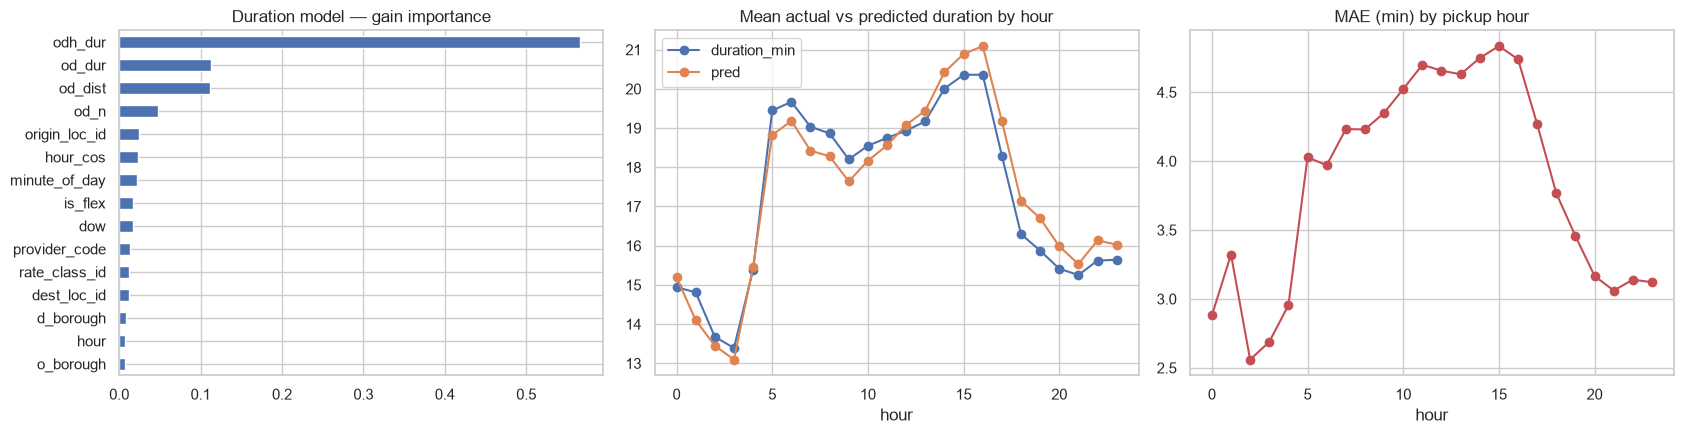

,n,MAE,MAPE_%
duration_min,,,
"(0, 10]",113400.0,2.58,50.82
"(10, 20]",132195.0,3.00,20.99
"(20, 30]",57495.0,4.60,18.98
"(30, 45]",27184.0,7.29,20.22
"(45, 60]",9560.0,10.08,19.64
"(60, 180]",7550.0,17.05,20.70


In [16]:
d = te_d.assign(pred=dur_pred, err=err, hour=te_d.pickup_timestamp.dt.hour)
by_len = d.groupby(pd.cut(d.duration_min, [0, 10, 20, 30, 45, 60, 180])).apply(
    lambda g: pd.Series({"n": len(g), "MAE": g.err.mean(), "MAPE_%": 100 * (g.err / g.duration_min).mean()})).round(2)
RESULTS["duration"]["by_trip_length"] = by_len.reset_index().astype(str).to_dict("records")
dc = FEATS_DUR + ["distance_miles"]
dur_ceiling = fit_lgb(RESULTS["duration"]["best_params"] | {"verbose": -1}, Xtr_c.loc[mtr, dc], tr_d.duration_min, Xva_c.loc[mva, dc], va.duration_min[mva])
RESULTS["duration"]["ceiling_with_metered_distance"] = reg_metrics(te_d.duration_min, dur_ceiling.predict(Xte_c.loc[mte, dc]))
print("Ceiling with metered distance (not deployable):", {k: round(v, 3) for k, v in RESULTS["duration"]["ceiling_with_metered_distance"].items()})

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
imp = pd.Series(dur_model.booster_.feature_importance("gain"), FEATS_DUR).sort_values().tail(15)
(imp / imp.sum()).plot.barh(ax=ax[0], title="Duration model — gain importance")
d.groupby("hour")[["duration_min", "pred"]].mean().plot(ax=ax[1], marker="o", title="Mean actual vs predicted duration by hour")
d.groupby("hour").err.mean().plot(ax=ax[2], marker="o", color="C3", title="MAE (min) by pickup hour")
savefig("04_duration_model")
by_len

In [17]:
dur_bundle = TripModel(dur_model, od, zones, FEATS_DUR, "duration_min").fit_categories(Xtr[FEATS_DUR])
joblib.dump(dur_bundle, ROOT / "models" / "duration_model.pkl")
demo.assign(eta_minutes=joblib.load(ROOT / "models" / "duration_model.pkl").predict(demo).round(1),
            origin=demo.origin_loc_id.map(zones.zone_name), dest=demo.dest_loc_id.map(zones.zone_name))

,pickup_timestamp,origin_loc_id,dest_loc_id,rider_count,provider_code,rate_class_id,is_flex,eta_minutes,origin,dest
0,2026-03-20 08:15,237,161,1,2,1,0,7.8,Upper East Side South,Midtown Center
1,2026-03-20 23:40,79,181,2,2,1,0,26.3,East Village,Park Slope
2,2026-03-21 17:30,132,230,1,1,2,0,62.1,JFK Airport,Times Sq/Theatre District


### 2.3 Does the preprocessing & feature engineering actually help? (ablation)
Each row retrains LightGBM (default settings, same temporal split, same **clean** test set) with one ingredient removed.
*No row-cleaning* trains on every sampled row (only the imputations applied) — i.e. reversals, zero-odometer and corrupt-clock trips included.

In [18]:
raw_i = clean(raw, drop_rows=False)
tr_raw = raw_i[raw_i.src_month <= "2025-12"].reset_index(drop=True)
va_raw = raw_i[raw_i.src_month == "2026-01"].reset_index(drop=True)
od_raw = OdStats().fit(tr_raw)
Xtr_raw, Xva_raw, Xte_rawod = (build_features(d, od_raw, zones) for d in (tr_raw, va_raw, te))
CORRIDOR = ["od_dist", "od_dur", "odh_dur", "od_n"]
ZONE_IDS = ["origin_loc_id", "dest_loc_id"]

def ablate(target, feats, mask_tr, mask_va, mask_te):
    rows = {}
    ytr, yva, yte = tr[target][mask_tr], va[target][mask_va], te[target][mask_te]
    variants = {"Full pipeline (final features)": feats,
                "− corridor statistics": [f for f in feats if f not in CORRIDOR],
                "− zone IDs (boroughs only)": [f for f in feats if f not in ZONE_IDS],
                "± t_index (toggled)": [f for f in feats if f != "t_index"] if "t_index" in feats else feats + ["t_index"]}
    for name, cols in variants.items():
        m = fit_lgb(BASE_PARAMS, Xtr.loc[mask_tr, cols], ytr, Xva.loc[mask_va, cols], yva)
        rows[name] = reg_metrics(yte, m.predict(Xte.loc[mask_te, cols]))
    rtr, rva = tr_raw[target].notna(), va_raw[target].notna()
    m = fit_lgb(BASE_PARAMS, Xtr_raw.loc[rtr, feats], tr_raw[target][rtr], Xva_raw.loc[rva, feats], va_raw[target][rva])
    rows["− row cleaning (train on raw rows)"] = reg_metrics(yte, m.predict(Xte_rawod.loc[mask_te, feats]))
    return pd.DataFrame(rows).T.round(3)

all_tr, all_va, all_te = (pd.Series(True, index=d.index) for d in (tr, va, te))
abl_fare = ablate("base_fare", FEATS_FARE, all_tr, all_va, all_te)
abl_dur = ablate("duration_min", FEATS_DUR, mtr, mva, mte)
RESULTS["ablation"] = {"fare": abl_fare.reset_index().rename(columns={"index": "variant"}).to_dict("records"),
                       "duration": abl_dur.reset_index().rename(columns={"index": "variant"}).to_dict("records")}
display(abl_fare.add_prefix("fare_")); abl_dur.add_prefix("duration_")

,fare_MAE,fare_RMSE,fare_R2,fare_MedAE
Full pipeline (final features),3.867,7.153,0.828,2.350
− corridor statistics,3.917,7.181,0.827,2.415
− zone IDs (boroughs only),3.927,7.348,0.819,2.341
± t_index (toggled),4.144,7.851,0.793,2.325
− row cleaning (train on raw rows),4.093,7.558,0.808,2.441


,duration_MAE,duration_RMSE,duration_R2,duration_MedAE
Full pipeline (final features),3.976,6.325,0.803,2.701
− corridor statistics,3.980,6.280,0.806,2.738
− zone IDs (boroughs only),4.073,6.530,0.790,2.741
± t_index (toggled),4.157,6.687,0.780,2.743
− row cleaning (train on raw rows),4.322,7.110,0.751,2.867


**Takeaways.**
* **Row cleaning is the biggest single gain** — training on raw rows costs 0.020 R² on fare and 0.052 R² on duration: reversals, odometer failures and corrupt clocks teach the model wrong prices and times.
* **`t_index` is target-specific**: removing it costs the fare model 0.035 R² (it carries the Dec-2025 Flex repricing forward), while adding it to the duration model costs 0.023 R² (traffic has no trend to learn). Hence different feature sets for the two final models.
* **Zone identity** adds ≈0.01 R² to both models on top of boroughs.
* **Corridor statistics add little once zone IDs are present** — the trees learn origin × destination interactions directly from the IDs. We keep them because they are the fallback for rare or unseen corridors (back-off to zone/global medians) and make the model's inputs interpretable (an explicit expected distance/time), at no accuracy cost.

## 3. Spatial-temporal & demand analytics
### 3.1 The fleet dispatcher — pickups per zone, 24–72 h ahead
**Setup.** Hourly pickups (all genuine pickups in the full 48.6 M, not the sample) for the **10 busiest zones** (≈ 34 % of all trips).
Each day at 23:00 the dispatcher issues a forecast for the next 72 hours.

**Model.** One *global, direct multi-horizon* LightGBM (Poisson objective for counts). A training row is (zone, forecast origin, horizon h);
features use only data up to the origin: same hour-of-week over the last 1–4 weeks, the same hour on the latest observed day,
last-24h / last-168h levels, a recent-level ratio, calendar and holiday flags, zone and h.
**Baselines:** seasonal naïve (same hour last week) and 4-week hour-of-week average — the standard dispatch heuristics.

**Split:** train origins Apr-28 → Jan-28 · validation Jan-29 → Feb-25 · test Feb-26 → Mar-28 (forecasts cover to Mar-31).
**Metrics:** MAE/RMSE (pickups per zone-hour), **WAPE** (total absolute error ÷ total demand — robust to low-volume hours, unlike MAPE), R².

In [19]:
hourly = con.sql("SELECT * FROM 'data/agg/hourly_*.parquet'").df()
TOP = hourly.groupby("loc_id").pickups.sum().nlargest(10).index.tolist()
print("Top zones:", [f"{z} {zones.zone_name[z]}" for z in TOP])
print(f"Share of all pickups: {hourly[hourly.loc_id.isin(TOP)].pickups.sum() / hourly.pickups.sum():.1%}")
M = hourly_matrix(hourly, TOP)
origins = lambda a, b: list(pd.date_range(a, b, freq="D") + pd.Timedelta(hours=23))
dtr, dva, dte = make_rows(M, origins("2025-04-28", "2026-01-28")), make_rows(M, origins("2026-01-29", "2026-02-25")), make_rows(M, origins("2026-02-26", "2026-03-28"))
for n, d_ in [("train", dtr), ("val", dva), ("test", dte)]:
    d_.to_parquet(ROOT / "data" / "splits" / f"demand_{n}.parquet", index=False); print(n, len(d_))

Top zones: ['237 Upper East Side South', '161 Midtown Center', '132 JFK Airport', '236 Upper East Side North', '186 Penn Station/Madison Sq West', '162 Midtown East', '230 Times Sq/Theatre District', '142 Lincoln Square East', '138 LaGuardia Airport', '170 Murray Hill']
Share of all pickups: 34.3%


train 198000
val 20160
test 22320


In [20]:
dem_space = dict(num_leaves=[31, 63, 127], min_child_samples=[20, 50, 100], learning_rate=[0.03, 0.05], colsample_bytree=[0.7, 0.9])
rng = np.random.default_rng(SEED); rows = []
for i in range(8):
    p = dict(n_estimators=5000, subsample=0.8, subsample_freq=1, objective="poisson", verbose=-1, random_state=SEED,
             **{k: v[rng.integers(len(v))] for k, v in dem_space.items()})
    m = lgb.LGBMRegressor(**p).fit(dtr[DEMAND_FEATURES], dtr.y, eval_set=[(dva[DEMAND_FEATURES], dva.y)], callbacks=[lgb.early_stopping(200, verbose=False)])
    rows.append({**{k: p[k] for k in dem_space}, "iters": m.best_iteration_, "val_WAPE": demand_metrics(dva.y, m.predict(dva[DEMAND_FEATURES]))["WAPE_%"], "model": m})
dem_search = pd.DataFrame(rows).sort_values("val_WAPE").reset_index(drop=True)
demand_model = dem_search.loc[0, "model"]
display(dem_search.drop(columns="model").head().round(3))
dte["pred"] = demand_model.predict(dte[DEMAND_FEATURES])
dcomp = pd.DataFrame({"Seasonal naive (same hour last week)": demand_metrics(dte.y, dte.lag_1w),
                      "4-week hour-of-week mean": demand_metrics(dte.y, dte.how_mean_4w),
                      "LightGBM global (tuned)": demand_metrics(dte.y, dte.pred)}).T.round(3)
by_h = dte.groupby(pd.cut(dte.h, [0, 24, 48, 72], labels=["1-24h", "25-48h", "49-72h"])).apply(lambda g: pd.Series(demand_metrics(g.y, g.pred))).round(3)
by_zone = dte.groupby("loc_id", observed=True).apply(lambda g: pd.Series(demand_metrics(g.y, g.pred) | {"naive_WAPE_%": demand_metrics(g.y, g.lag_1w)["WAPE_%"]})).round(2)
by_zone.index = [zones.zone_name[z] for z in by_zone.index]
RESULTS["demand"] = {"comparison": dcomp.reset_index().rename(columns={"index": "model"}).to_dict("records"),
                     "by_horizon": by_h.reset_index().to_dict("records"), "by_zone": by_zone.reset_index().to_dict("records"),
                     "top_zones": [zones.zone_name[z] for z in TOP]}
display(dcomp); display(by_h); by_zone

,num_leaves,min_child_samples,learning_rate,colsample_bytree,iters,val_WAPE
0,63,50,0.03,0.7,502,18.703
1,127,50,0.03,0.9,1495,18.737
2,31,20,0.05,0.9,1465,18.772
3,63,20,0.05,0.7,970,18.775
4,63,50,0.03,0.9,1105,18.776


,MAE,RMSE,WAPE_%,R2
Seasonal naive (same hour last week),38.556,64.756,22.084,0.784
4-week hour-of-week mean,31.418,49.998,17.996,0.871
LightGBM global (tuned),28.129,44.461,16.112,0.898


,MAE,RMSE,WAPE_%,R2
h,,,,
1-24h,27.373,43.590,15.666,0.902
25-48h,28.416,44.976,16.320,0.895
49-72h,28.599,44.804,16.350,0.897


,MAE,RMSE,WAPE_%,R2,naive_WAPE_%
JFK Airport,36.88,52.65,18.53,0.83,25.91
LaGuardia Airport,32.66,50.76,25.86,0.71,36.46
Lincoln Square East,26.07,42.50,17.42,0.84,23.68
Midtown Center,32.47,54.93,14.88,0.92,19.57
Midtown East,23.56,38.19,14.62,0.91,19.81
Murray Hill,18.80,27.21,13.73,0.91,18.80
Penn Station/Madison Sq West,27.32,41.38,16.96,0.79,23.31
Times Sq/Theatre District,23.13,35.86,15.29,0.91,19.56
Upper East Side North,30.37,47.80,14.44,0.92,20.26
Upper East Side South,30.04,45.97,12.95,0.93,18.27


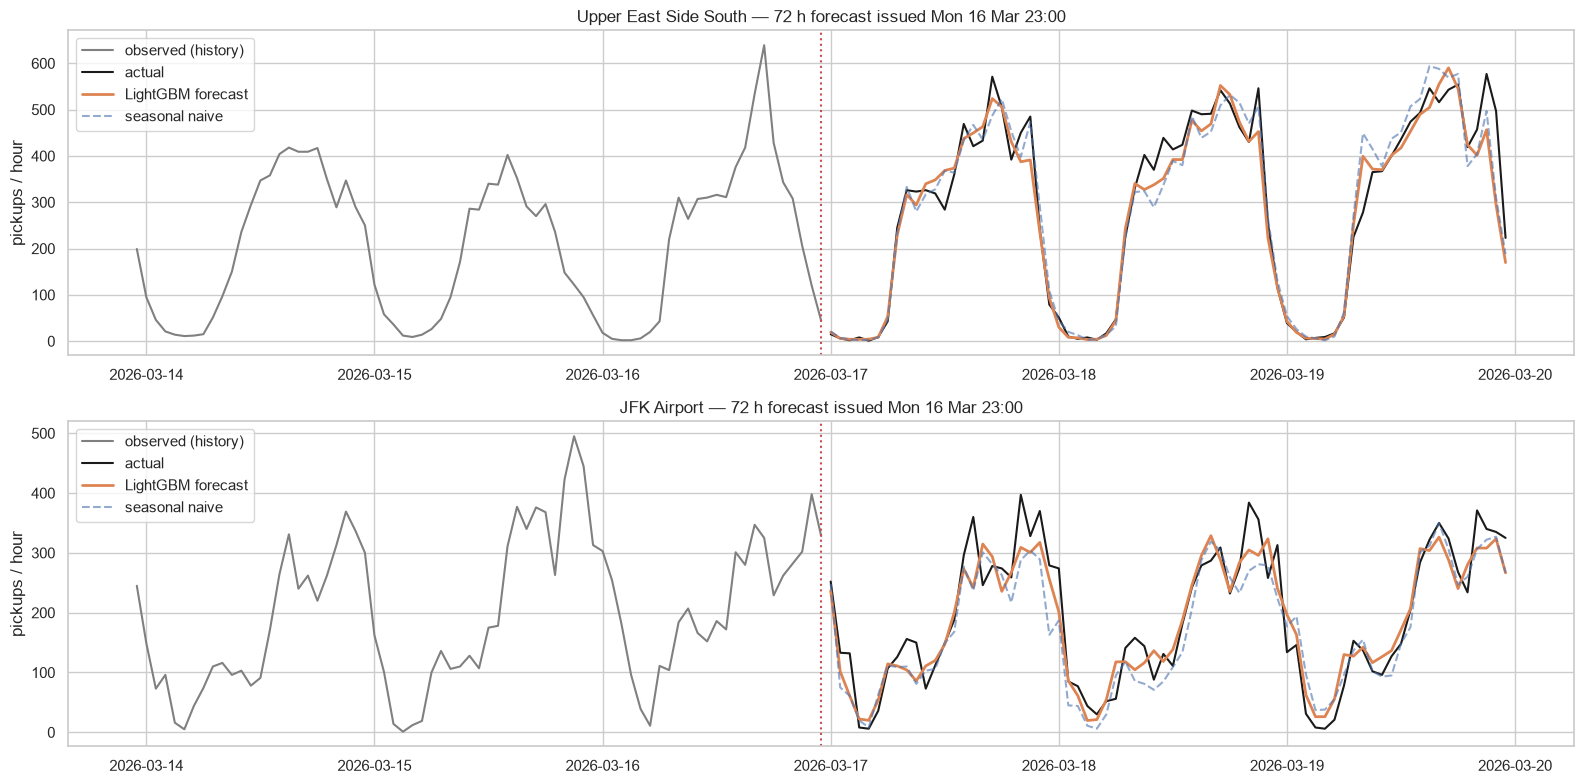

['/Users/chanukajanandhana/Documents/Y2S1/Codefest/Datathon/Atreides_CodefestDatathon2026/models/demand_model.pkl']

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
for ax, z in zip(axes, [TOP[0], 132]):
    o = pd.Timestamp("2026-03-16 23:00")
    w = dte[(dte.origin == o) & (dte.loc_id == z)]
    hist = M[z].loc[o - pd.Timedelta(hours=72): o]
    ax.plot(hist.index, hist.values, color="grey", label="observed (history)")
    ax.plot(w.target_time, w.y, "k", label="actual"); ax.plot(w.target_time, w.pred, "C1", lw=2, label="LightGBM forecast")
    ax.plot(w.target_time, w.lag_1w, "C0--", alpha=.6, label="seasonal naive")
    ax.axvline(o, color="r", ls=":"); ax.set(title=f"{zones.zone_name[z]} — 72 h forecast issued {o:%a %d %b %H:%M}", ylabel="pickups / hour"); ax.legend(loc="upper left")
savefig("05_demand_forecast")
joblib.dump({"model": demand_model, "features": DEMAND_FEATURES, "zones": TOP,
             "note": "use demand.make_rows(hourly_matrix, [origin]) to build inputs; horizon 1-72h"}, ROOT / "models" / "demand_model.pkl")

### 3.2 Hotspots & origin-destination flow clustering
**Step 1 — zone archetypes.** Every zone (≥ 2,000 trips/year) is described by *when* it generates and attracts trips: the share of its
pickups and drop-offs in each of five time bands, its pickup/drop-off balance, log volume and weekend share. K-Means (standardised features)
groups zones that behave alike; k is chosen from the silhouette curve plus interpretability.

**Step 2 — flows between archetypes.** The 45.8 M genuine trips are aggregated to archetype→archetype flows per time band, turning
35 k zone-pairs into a readable picture of how the city moves from the morning commute to late night.

In [22]:
odf = con.sql("SELECT origin_loc_id o, dest_loc_id d, band, weekend, sum(trips) trips FROM 'data/agg/od_*.parquet' GROUP BY ALL").df()
BANDS = ["morning_peak", "midday", "evening_peak", "night", "late_night"]
pu = odf.groupby(["o", "band"]).trips.sum().unstack().reindex(columns=BANDS).fillna(0)
do = odf.groupby(["d", "band"]).trips.sum().unstack().reindex(columns=BANDS).fillna(0)
idx = pu.index.union(do.index); pu, do = pu.reindex(idx).fillna(0), do.reindex(idx).fillna(0)
wk = odf.groupby(["o", "weekend"]).trips.sum().unstack().reindex(idx).fillna(0)
tot = pu.sum(1) + do.sum(1)
F = pd.concat([pu.div(pu.sum(1) + 1, axis=0).add_prefix("pu_"), do.div(do.sum(1) + 1, axis=0).add_prefix("do_"),
               (pu.sum(1) / (tot + 1)).rename("pickup_share"), np.log1p(tot).rename("log_volume"),
               (wk[True] / (wk.sum(1) + 1)).rename("weekend_share")], axis=1)
F = F[tot >= 2000]
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
Xs = StandardScaler().fit_transform(F)
sil = {k: silhouette_score(Xs, KMeans(k, n_init=20, random_state=SEED).fit_predict(Xs)) for k in range(3, 11)}
print({k: round(v, 3) for k, v in sil.items()})

{3: 0.283, 4: 0.247, 5: 0.237, 6: 0.203, 7: 0.184, 8: 0.191, 9: 0.191, 10: 0.186}


In [23]:
K = 6
km = KMeans(K, n_init=50, random_state=SEED).fit(Xs)
F["cluster"] = km.labels_
prof = F.groupby("cluster").mean()
def name_cluster(r):
    if r.log_volume == prof.log_volume.max(): return "Manhattan core (business & transit hubs)"
    if r.pu_late_night == prof.pu_late_night.max(): return "Nightlife districts"
    if r.pu_morning_peak == prof.pu_morning_peak.max(): return "Outer-borough residential (morning origins)"
    if r.pu_midday == prof.pu_midday.max(): return "Peripheral / low-volume & airports"
    if r.log_volume == prof.log_volume.nlargest(2).iloc[-1]: return "Mixed-use Manhattan (dining & residential)"
    return "Uptown & Queens residential"
names = {c: name_cluster(r) for c, r in prof.iterrows()}
F["archetype"] = F.cluster.map(names)
F = F.join(zones)
summary = F.groupby("archetype").agg(zones=("zone_name", "size"), examples=("zone_name", lambda s: ", ".join(s.loc[F.loc[s.index].log_volume.sort_values(ascending=False).index[:4]])),
                                     morning_pu=("pu_morning_peak", "mean"), late_night_pu=("pu_late_night", "mean"), weekend=("weekend_share", "mean"))
RESULTS["clusters"] = {"k": K, "silhouette": {int(k): round(float(v), 3) for k, v in sil.items()},
                       "summary": summary.round(3).reset_index().to_dict("records")}
summary.round(3)

,zones,examples,morning_pu,late_night_pu,weekend
archetype,,,,,
Manhattan core (business & transit hubs),41,"Upper East Side South, Upper East Side North, ...",0.129,0.063,0.266
Mixed-use Manhattan (dining & residential),25,"Clinton East, West Village, Gramercy, Flatiron",0.135,0.136,0.351
Nightlife districts,14,"East Village, Lower East Side, Alphabet City, ...",0.121,0.331,0.503
Outer-borough residential (morning origins),75,"East New York, Prospect-Lefferts Gardens, Flat...",0.324,0.121,0.279
Peripheral / low-volume & airports,21,"LaGuardia Airport, East Harlem South, Newark A...",0.202,0.072,0.260
Uptown & Queens residential,58,"Central Harlem North, Washington Heights South...",0.220,0.139,0.331


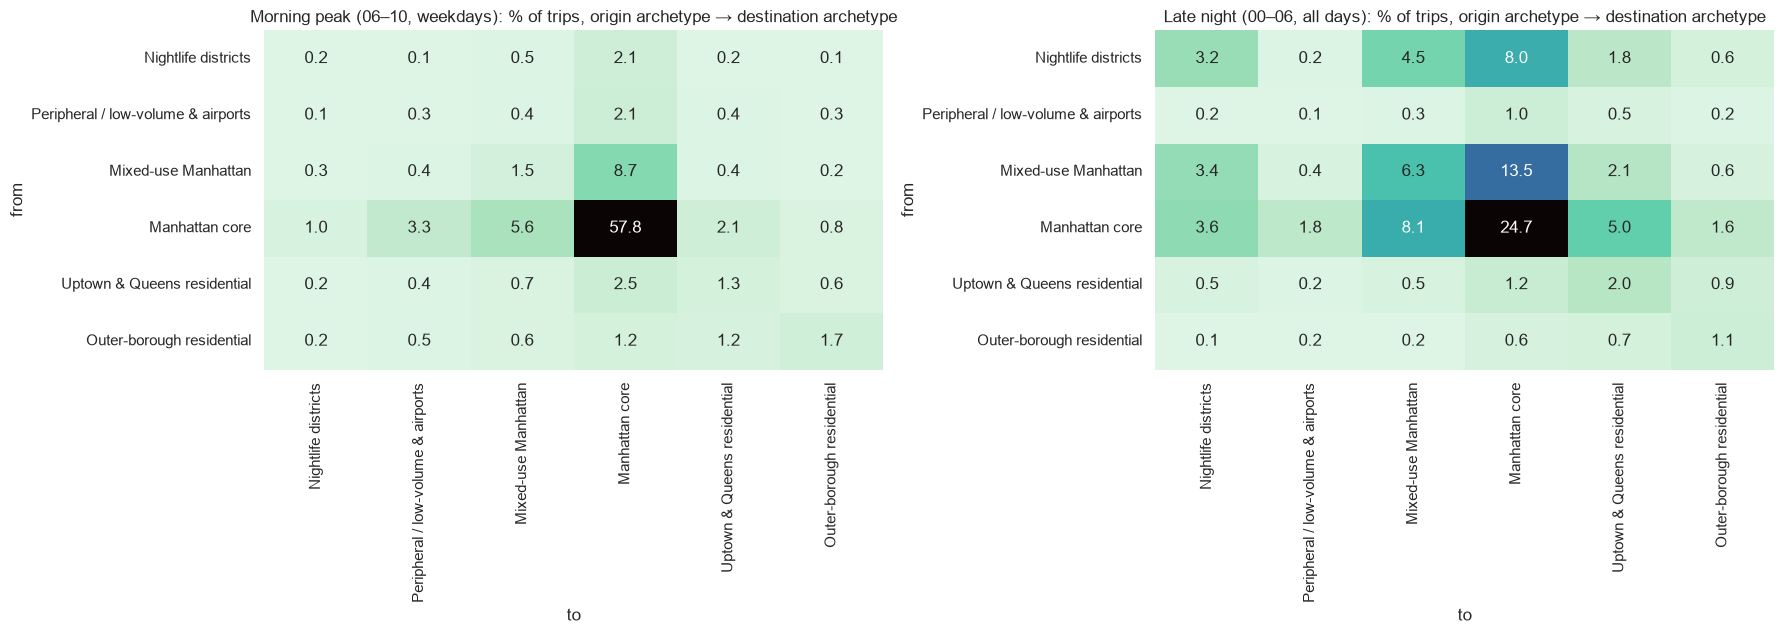

In [24]:
F[["zone_name", "borough_name", "archetype"]].rename_axis("loc_id").reset_index().to_csv(ROOT / "reports" / "zone_archetypes.csv", index=False)
arch = F.archetype
fl = odf[odf.o.isin(arch.index) & odf.d.isin(arch.index)].assign(oa=lambda x: x.o.map(arch), da=lambda x: x.d.map(arch))
order = list(summary.sort_values("zones").index)
short = {a: a.split(" (")[0] for a in order}
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, b, t in zip(axes, ["morning_peak", "late_night"], ["Morning peak (06–10, weekdays)", "Late night (00–06, all days)"]):
    sub = fl[(fl.band == b) & ((~fl.weekend) if b == "morning_peak" else True)]
    mat = sub.pivot_table(index="oa", columns="da", values="trips", aggfunc="sum").reindex(index=order, columns=order).fillna(0)
    sns.heatmap(100 * mat / mat.values.sum(), annot=True, fmt=".1f", cmap="mako_r", ax=ax, cbar=False,
                xticklabels=[short[a] for a in order], yticklabels=[short[a] for a in order])
    ax.set(title=f"{t}: % of trips, origin archetype → destination archetype", xlabel="to", ylabel="from")
savefig("06_od_flows_by_band")

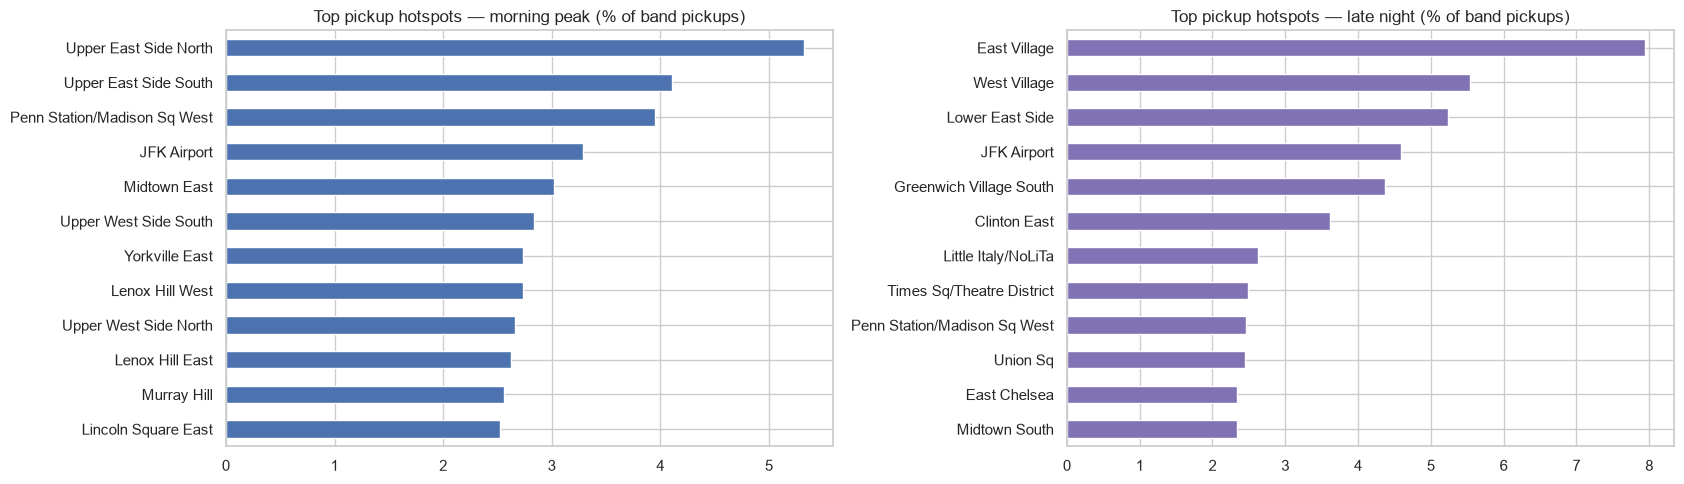

,corridor,trips
0,Upper East Side North → Midtown Center,36413.0
1,Upper East Side North → Upper East Side South,35645.0
2,Upper East Side South → Upper East Side North,34278.0
3,Upper East Side South → Midtown Center,26643.0
4,Upper East Side North → Midtown East,24425.0
5,Penn Station/Madison Sq West → Union Sq,22264.0
6,Penn Station/Madison Sq West → Midtown Center,21861.0
7,Upper East Side South → Midtown East,20316.0


,corridor,trips
0,West Village → East Village,17069.0
1,East Village → Murray Hill,16075.0
2,Lower East Side → East Village,15167.0
3,East Village → Gramercy,13859.0
4,East Village → Lower East Side,13208.0
5,East Village → Kips Bay,13119.0
6,Greenwich Village South → East Village,12149.0
7,East Village → West Village,12044.0


In [25]:
corr = odf.groupby(["o", "d", "band"]).trips.sum().reset_index()
corr["corridor"] = corr.o.map(zones.zone_name) + " → " + corr.d.map(zones.zone_name)
top_corr = {b: corr[(corr.band == b) & (corr.o != corr.d)].nlargest(8, "trips")[["corridor", "trips"]].reset_index(drop=True) for b in ["morning_peak", "late_night"]}
RESULTS["clusters"]["top_corridors"] = {b: t.to_dict("records") for b, t in top_corr.items()}
hot = odf.groupby(["o", "band"]).trips.sum().unstack()[BANDS]
hot_share = hot.div(hot.sum()).mul(100)
fig, ax = plt.subplots(1, 2, figsize=(17, 5))
for a, b in zip(ax, ["morning_peak", "late_night"]):
    s = hot_share[b].nlargest(12)[::-1]; s.index = [zones.zone_name[i] for i in s.index]
    s.plot.barh(ax=a, color="C0" if b == "morning_peak" else "C4", title=f"Top pickup hotspots — {b.replace('_', ' ')} (% of band pickups)")
savefig("07_hotspots_morning_vs_night")
display(top_corr["morning_peak"]); top_corr["late_night"]

**What the clusters show**
* **Morning peak:** movement is concentrated — ~58 % of weekday-morning trips stay *inside* the Manhattan core (Upper East Side ↔ Midtown, Penn Station → Midtown/Union Sq). Trips starting in nightlife or mixed-use zones are only ~15 %.
* **Late night:** the centre of gravity shifts south and east. Nightlife and mixed-use zones originate ~45 % of trips (East Village, Lower East Side, West Village, Williamsburg), and the top corridors become short hops between them (West Village → East Village, Lower East Side → East Village). Core-internal trips fall to ~25 %.
* **Airports** (JFK, LaGuardia) are hotspots in every band and dominate long, high-fare trips — ideal for pre-positioning in the forecast model.
* **Dispatch implication:** reposition idle cabs from Midtown to the nightlife cluster after 22:00 and back to residential zones before 07:00; combine with the 72-h zone forecast from 3.1.

## 4. Architecture, metric rationale & results summary

The solution architecture is drawn in draw.io and exported to `reports/figures/00_architecture.png` (editable source: `tools/architecture/architecture.drawio`, outside the submission folder).

![Solution architecture](reports/figures/00_architecture.png)

### Why these metrics
| Metric | Used for | Why |
|---|---|---|
| **MAE** | fare ($), duration (min), demand (pickups) | Same unit as the target; "average surprise" a rider or dispatcher experiences; robust to the heavy tails that survive cleaning. Primary metric for comparing models. |
| **RMSE** | all regressions (also the tuning objective) | Squares errors, so it punishes the rare big miss — the case that destroys trust in a locked-in price or ETA. RMSE ≫ MAE flags a heavy error tail. |
| **R²** | all regressions | Scale-free share of variance explained; lets us compare fare vs duration models and against baselines on one axis. |
| **Median AE, % within ±$5 / ±2 min / ±5 min** | fare, duration | Business-facing: the typical rider experience and the share of "on-promise" predictions. |
| **WAPE** | demand | Total error ÷ total demand; stable when some zone-hours have few pickups (MAPE explodes there) and reads directly as "% of fleet mis-allocated". |

Every model is compared against naïve baselines on the **same untouched future test period**, so gains are real, not artefacts of leakage.

In [27]:
(ROOT / "reports").mkdir(exist_ok=True)
json.dump(RESULTS, open(ROOT / "reports" / "results.json", "w"), indent=2, default=float)
summary_rows = []
for task, key in [("Upfront fare ($)", "fare"), ("Trip duration (min)", "duration")]:
    best = RESULTS[key]["final"]; base = RESULTS[key]["comparison"][1]
    summary_rows.append({"task": task, "model": RESULTS[key]["selected"], "MAE": best["MAE"], "RMSE": best["RMSE"], "R2": best["R2"],
                         "best baseline MAE": base["MAE"], "MAE improvement %": 100 * (1 - best["MAE"] / base["MAE"])})
b = RESULTS["demand"]["comparison"]
summary_rows.append({"task": "Zone demand 1–72 h (pickups/h)", "model": "LightGBM global", "MAE": b[2]["MAE"], "RMSE": b[2]["RMSE"], "R2": b[2]["R2"],
                     "best baseline MAE": b[1]["MAE"], "MAE improvement %": 100 * (1 - b[2]["MAE"] / b[1]["MAE"])})
pd.DataFrame(summary_rows).round(3)

,task,model,MAE,RMSE,R2,best baseline MAE,MAE improvement %
0,Upfront fare ($),LightGBM (tuned),3.874,7.169,0.827,4.901,20.961
1,Trip duration (min),LightGBM (tuned),3.961,6.311,0.804,5.026,21.195
2,Zone demand 1–72 h (pickups/h),LightGBM global,28.129,44.461,0.898,31.418,10.469


### Key findings & business implications
1. **Data quality is a business issue, not just a cleaning step.** ~9 % of records cannot be used for pricing; one provider emits all reversals and another never records drop-off time. Provider-level data SLAs would recover this.
2. **Upfront pricing is feasible now for metered trips** (see segment table): errors are small enough to lock prices with a modest buffer. Flex-Fare trips carry most of the error because their prices are already algorithmic and changed regime in Dec 2025 — the pricing engine should be retrained monthly and monitored for drift.
3. **Route knowledge is the biggest lever.** The ceiling experiment shows how much accuracy a routing engine's distance estimate would add to both fare and ETA.
4. **Demand is highly predictable 72 h ahead** in the top zones and the global model beats standard dispatcher heuristics at every horizon — enough to schedule shifts and pre-position cabs a day or three in advance.
5. **The city has distinct daily rhythms**: residential → core in the morning, nightlife → residential late at night, airports all day. Repositioning cabs to follow these flows reduces empty cruising.